In [ ]:
# recurrent dropout 적용
"""
    recurrent_dropout을 적용하고 gru를 사용한 모델을 구현한다
"""

In [1]:
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Masking
import wandb
from wandb.integration.keras import WandbCallback
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import pandas as pd


In [2]:


MAX_SEQ_LEN = 101  # 예시 최대 시퀀스 길이
FEATURE_DIM = 84  # 키포인트 feature 벡터 길이
NUM_CLASSES = 133  # 총 클래스 개수 (논문에 맞게 조정)
BATCH_SIZE = 32
EPOCHS =60


def load_npz_file(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    keypoints = data['keypoints']  # (time_steps, feature_dim)
    label = data['label'].item()

    # 1) 빈 배열 또는 차원 오류 체크
    if keypoints.size == 0:
        print(f"⚠️Skipping {npz_path}: keypoints is empty.")
        return
    if keypoints.ndim != 2:
        print(f"⚠️Skipping {npz_path}: expected 2D but got {keypoints.ndim}D, shape={keypoints.shape}")
        return
    if keypoints.shape[0] < 10:
        print(f"⚠️Skipping {npz_path}: too short, shape={keypoints.shape}")
        return

    # padding or trimming
    if keypoints.shape[0] > MAX_SEQ_LEN:
        keypoints = keypoints[:MAX_SEQ_LEN]
    else:
        pad_len = MAX_SEQ_LEN - keypoints.shape[0]
        pad_array = np.zeros((pad_len, FEATURE_DIM), dtype=np.float32)
        keypoints = np.vstack([keypoints, pad_array])
    return keypoints.astype(np.float32), label

def create_dataset(npz_files):
    X, y = [], []
    for npz_path in npz_files:
        re = load_npz_file(npz_path)
        if re is None:
            continue
        keypoints, label = re
        X.append(keypoints)
        y.append(label)
    X = np.array(X)
    y = np.array(y)
    return X, y

folder_path = 'data01-norm'  # npz 파일이 있는 폴더 경로
folder_path2 = 'data02-norm'  # npz 파일이 있는 폴더 경로
folder_path3 = 'data03-norm'
folder_path4 = 'data04-norm'
folder_path5 = 'data05-norm'
folder_path6 = 'data06-norm'
folder_path7 = 'data07-norm'
folder_path8 = 'data08-norm'
folder_path9 = 'data09-norm'
folder_path10 = 'data10-norm'


npz_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.npz')]
npz_files2 = [os.path.join(folder_path2, f) for f in os.listdir(folder_path2) if f.endswith('.npz')]
npz_files3 = [os.path.join(folder_path3, f) for f in os.listdir(folder_path3) if f.endswith('.npz')]
npz_files4 = [os.path.join(folder_path4, f) for f in os.listdir(folder_path4) if f.endswith('.npz')]
npz_files5 = [os.path.join(folder_path5, f) for f in os.listdir(folder_path5) if f.endswith('.npz')]
npz_files6 = [os.path.join(folder_path6, f) for f in os.listdir(folder_path6) if f.endswith('.npz')]
npz_files7 = [os.path.join(folder_path7, f) for f in os.listdir(folder_path7) if f.endswith('.npz')]
npz_files8 = [os.path.join(folder_path8, f) for f in os.listdir(folder_path8) if f.endswith('.npz')]
npz_files9 = [os.path.join(folder_path9, f) for f in os.listdir(folder_path9) if f.endswith('.npz')]
npz_files10 = [os.path.join(folder_path10, f) for f in os.listdir(folder_path10) if f.endswith('.npz')]

all_npz_files = npz_files + npz_files2 + npz_files3 + npz_files4 + npz_files5 + npz_files6 + npz_files7 + npz_files8 + npz_files9 + npz_files10
print(all_npz_files)
print(npz_files)
X, y = create_dataset(all_npz_files)

print(f"X shape: {X.shape}")
pd.set_option('display.max_rows', None)
df = pd.DataFrame({'y': y})
print(df['y'].value_counts())


['data01-norm/NIA_SL_WORD0501_REAL01_F.npz', 'data01-norm/NIA_SL_WORD1189_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0288_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0097_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0237_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0262_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0312_REAL01_F.npz', 'data01-norm/NIA_SL_WORD1528_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0452_REAL01_F.npz', 'data01-norm/NIA_SL_WORD2205_REAL01_F.npz', 'data01-norm/NIA_SL_WORD2573_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0336_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0059_REAL01_F.npz', 'data01-norm/NIA_SL_WORD1877_REAL01_F.npz', 'data01-norm/NIA_SL_WORD1162_REAL01_F.npz', 'data01-norm/NIA_SL_WORD1529_REAL01_F.npz', 'data01-norm/NIA_SL_WORD2235_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0301_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0289_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0271_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0119_REAL01_F.npz', 'data01-norm/NIA_SL_WORD0212_REAL01_F.npz', 'data01-norm/NIA_SL_WORD2179_RE

In [3]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# 3) 배치 및 최적화
train_dataset = train_dataset.shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(1).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(1).prefetch(tf.data.AUTOTUNE)

In [4]:
model = Sequential([
    Masking(mask_value=0.0, input_shape=(MAX_SEQ_LEN, FEATURE_DIM)),  # 0으로 패딩된 부분 무시
    GRU(128, 
        input_shape=(MAX_SEQ_LEN, FEATURE_DIM), 
        return_sequences=True,    # 1번째 GRU는 시퀀스 전체 출력
        recurrent_dropout=0.5),
    GRU(128, 
        return_sequences=False,   # 2번째 GRU는 마지막 타임스텝 출력만
        recurrent_dropout=0.5),
    # Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/opt/anaconda3/envs/p-project/lib/python3.9/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/anaconda3/envs/p-project/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 101, 84)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 101, 128)       │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 133)            │        17,157 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,405 (775.02 KB)

 Trainable params: 198,405 (775.02 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
wandb.init(project="sign-language-gru-tensorflow")  # 프로젝트 이름과 엔티티 이름을 설정하세요.
wandb.init(config={
    "learning_rate": 0.001,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "dropout_rate": 0.5
})

wandb: Currently logged in as: hjkim1770 (hjkim1770-gachon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:

# 학습
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']  # 정확도 측정 추가
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
)
# 평가(테스트 데이터셋이 있을 경우)
test_loss, test_acc = model.evaluate(test_dataset)

model.save('gru_tensor.h5')

# 불러오기
# from tensorflow.keras.models import load_model
# model = load_model('sign_language_gru_model.h5')

Epoch 1/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 271ms/step - accuracy: 0.0360 - loss: 4.7956 - val_accuracy: 0.1174 - val_loss: 4.2547
Epoch 2/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - accuracy: 0.1586 - loss: 4.0522 - val_accuracy: 0.2278 - val_loss: 3.6124
Epoch 3/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - accuracy: 0.2839 - loss: 3.4156 - val_accuracy: 0.3452 - val_loss: 3.0198
Epoch 4/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.3985 - loss: 2.8208 - val_accuracy: 0.4947 - val_loss: 2.5367
Epoch 5/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.5188 - loss: 2.3670 - val_accuracy: 0.6157 - val_loss: 2.1128
Epoch 6/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step - accuracy: 0.6120 - loss: 1.9871 - val_accuracy: 0.6512 - val_loss: 1.8139
Epoch 7/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step - accuracy: 0.7055 - loss: 1.6822 - val_accuracy: 0.7402 - val_loss: 1.5558
Epoch 8/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 268ms/step - accuracy: 0.7256 - loss: 1.4440 - val_accuracy: 0.

In [7]:
model.save('gru_tensor.keras')


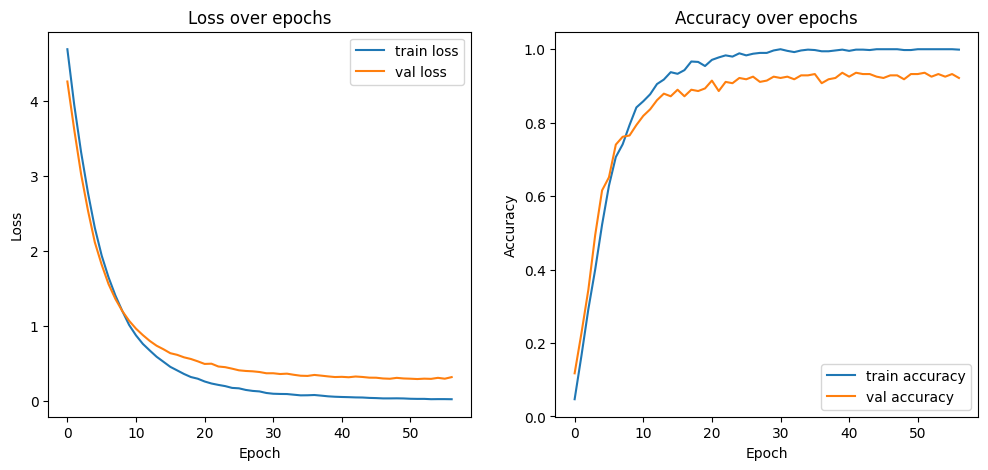

In [8]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # 손실 그래프
    plt.figure(figsize=(12, 5))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='val loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy
    plt.subplot(1, 2, 2)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='train accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

# 사용 예시
plot_training_history(history)
